# **Superstore Profitability & Forecasting Analysis**
### James Capone
### 2/15/26

## Executive Summary

This report analyzes a Superstore dataset sourced from Kaggle to evaluate profitability performance across key divisions of the business. Using structured analytical methodology, profit quality was assessed through margin stability, risk exposure, and contribution to overall performance.

Following the diagnostic analysis, historical profit data was used to develop a forecasting model to generate a 6-month forward projection. Multiple time-series approaches were examined using out-of-sample validation, with a 3-month rolling average model demonstrating the strongest predictive performance.

Key findings, performance metrics, and forecast projections were consolidated into a Power BI dashboard to support data-driven decision making. The analysis was conducted with executive stakeholders in mind, emphasizing actionable recommendations grounded in empirical evidence and retail sector dynamics.


*Superstore Dataset:* [https://www.kaggle.com/datasets/vivek468/superstore-dataset-final](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)

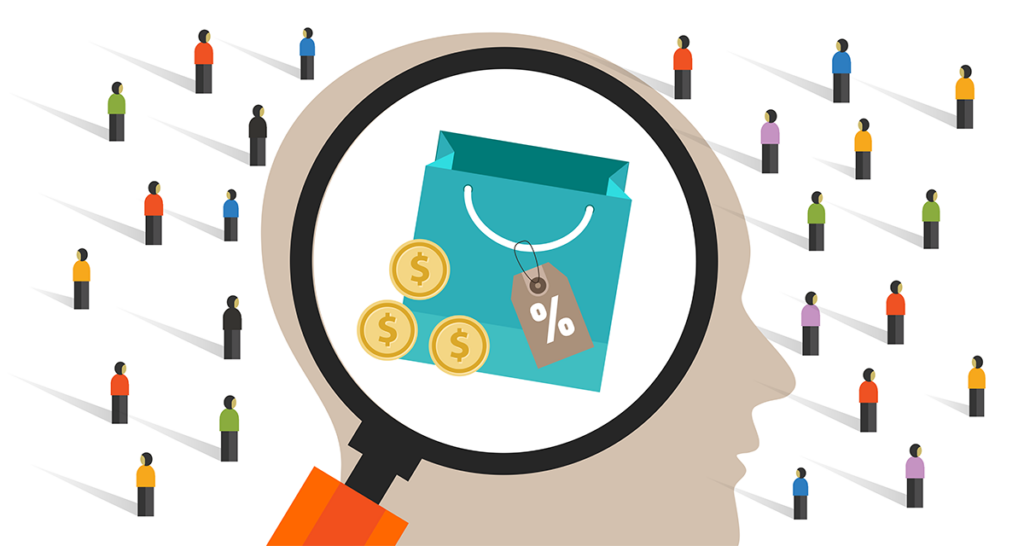
https://djcs-prod.s3.amazonaws.com/public/blogs/deloitte/blogs.dir/8/files/2022/03/The-Pandemics-Impact-IMAGE-1024x546.png

## Profit Analysis

The goal of this analysis is to identify which product categories, regions, and customer segments should be prioritized, optimized, or deprioritized based on their contribution to profitability and business risk. Rather than relying on sales volume alone, this analysis focuses on profit metrics that better reflect sustainabile business performance.

Before we can accomplish this goal, we must ensure the data is properly cleaned to prevent bad data from contaminating our analysis and future forecasting models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [2]:
raw_sales_data = pd.read_csv('Sample - Superstore.csv', encoding="ISO-8859-1")

In [3]:
df = raw_sales_data.copy()

In [4]:
# format column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

## Data Preparation & Feature Engineering

The dataset was first reviewed for structural integrity and consistency. Date fields were converted to datetime format to enable time-based grouping and forecasting. Column names were standardized, and the dataset did not contain any missing values that required attention.

Lastly, the profit margin column was created using the sales and profit metrics from the dataset.

In [5]:
df.isnull().sum()

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub-category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
# convert order date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# create year and month fields for aggregation
df['year'] = df['order_date'].dt.year
df['year_month'] = df['order_date'].dt.to_period('M').dt.to_timestamp()


In [8]:
# profit margin
df['profit_margin'] = df['profit'] / df['sales']

## Analysis Approach

As stated previously, the goal of this analysis is to identify which product categories, regions, and customer segments should be prioritized, optimized, or deprioritized based on their contribution to profitability and business risk.

For each group, performance is evaluated using total sales, aggregate profit, and share of total profit to measure overall contribution. Profit quality and consistency are assessed using average and median profit margins, while risk is evaluated using the negative margin rate which is the proportion of transactions that result in a loss. Pricing behavior is captured through median discount rates.

These metrics are analyzed collectively to classify each group as Target, Investigate, or Avoid. Groups that contribute significantly to total profit, maintain healthy margins, and exhibit low loss frequency are prioritized for growth. Groups that are profitable but inconsistent are flagged for further investigation, while groups that contribute little profit and exhibit high risk are deprioritized.

This structured approach ensures that recommendations are grounded in both financial contribution and operational stability, enabling more informed and sustainable business decisions.

## Category Assessment


### *Furniture:*

The Furniture category represents a **high-risk group**. As shown in the category profit share and negative margin rate charts, while it generates strong sales numbers at nearly \\$742,000, it contributes disproportionately little to overall profit at nearly 6% of profit share percentage for the group. Furniture produces the lowest total profit at roughly \\$18,500, significantly trailing the next closest category, Office Supplies, which generates nearly \\$122,500 in total profit. An average profit margin of just 4% further highlights the category's weak efficiency.

Although the typical Furniture transaction is profitable, with a median profit margin of 11%, overall performance remains inconsistent. Approximately 34% of Furniture transactions result in a negative profit margin, suggesting frequent unprofitable orders that erode overall performance. This instability likely contributes to the category's weak aggregate profit.

The typical Furniture transaction has a 20% discount, which could contribute to the diminishing margins. To improve profitibility, I would recommend scaling back discounting efforts within this category and closely monitor for changes in margins and overall profit. This may reduce overall sales, but it is likely to improve transaction quality and support long-term profitability.

### *Technology:*

The Technology category should be **targeted** for growth. As reflected in the profit share and margin charts, it generates the highest overall profit and generates roughly half of the category's profit share, maintains a strong average profit margin of approximately 16%, and demonstrates consistent performance, with roughly 85% of transactions producing positive profit margins. A median profit margin of 18% further indicates that the typical Technology transaction is highly profitable.

Despite strong performance, the typical Technology order still carries a median discount of 20%, suggesting potential opportunity to further improve margins through optimized discounting strategies. To enhance profitability, I would recommend selectively reducing discounts while monitoring impacts on sales volume, margin, and total profit. Additionally, increased advertising or promotional focus on Technology products could amplify returns given the category's already strong margin profile. 

### *Office Supplies:*

The Office Supplies category is another group to be **targeted**. As shown in the profit share and negative margin rate charts, it generates the second-highest total profit and contributes approximatley 43% of overall profit, demonstrating strong and consistent profitability with an average profit maring of 14%. In addition, Office Supplies exhibits one of the lowest negative margin rates at 15%, alongside having the highest median profit margin of a typical transactiona at 32%. This indicates high efficiency and reliable performance.

Despite having the lowest overall sales at nearly \\$719,047, the category's strong profitability outweighs the need to pursue actions to  increase additional sales volume. With the highest typical transaction profit margin and a median discount of 0, profits are being generated without price erosion from discounts. Rather than increasing sales through discounting, profit margins should be protected while focusing growth efforts on non-pricing strategies such as expanding inventory availability or bundling Office Supplies with Technology products.

In [9]:
category_summary = (
    df.groupby('category').agg(total_sales = ('sales', 'sum'),
                               total_profit = ('profit', 'sum'),
                               avg_profit_margin = ('profit_margin', 'mean'),
                               median_profit_margin = ('profit_margin', 'median'),
                               neg_margin_rate = ('profit_margin', lambda x: (x < 0).mean()),
                               median_discount = ('discount', 'median')
                              )
).round(2)

total_profit_all = category_summary['total_profit'].sum()

category_summary['profit_share_pct'] = round((category_summary['total_profit'] / total_profit_all) * 100, 2)

In [10]:
category_summary

,total_sales,total_profit,avg_profit_margin,median_profit_margin,neg_margin_rate,median_discount,profit_share_pct
category,,,,,,,
Furniture,741999.80,18451.27,0.04,0.11,0.34,0.2,6.44
Office Supplies,719047.03,122490.80,0.14,0.32,0.15,0.0,42.77
Technology,836154.03,145454.95,0.16,0.18,0.15,0.2,50.79


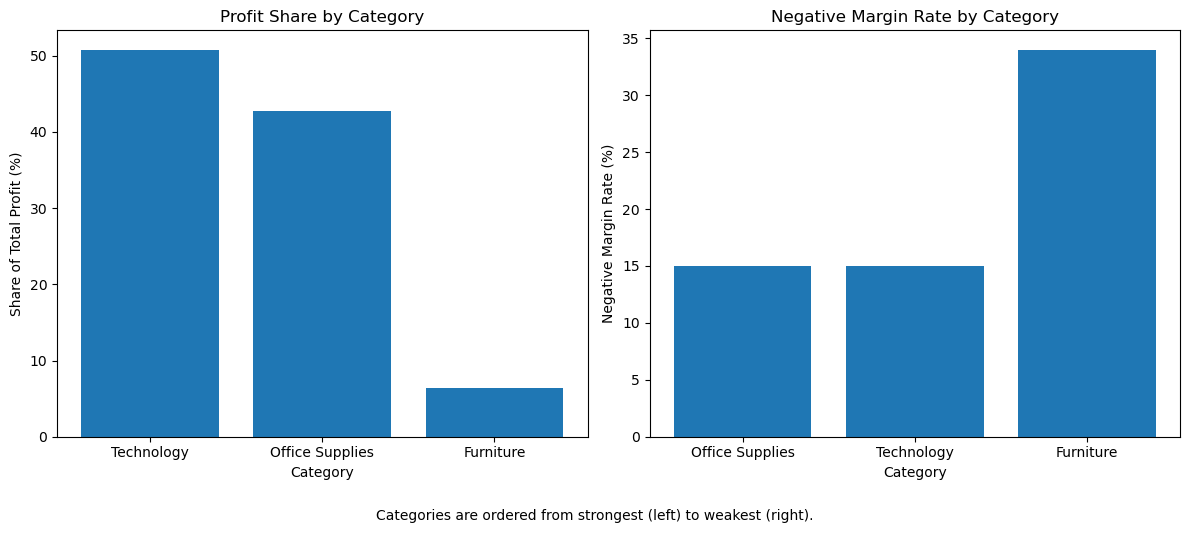

In [11]:
# sorting target values
profit_share_sorted = category_summary.sort_values(by = 'profit_share_pct', ascending = False)
neg_margin_sorted = category_summary.sort_values(by = 'neg_margin_rate', ascending = True)


# plotting profit share by category (value) & negative margin rate (risk)

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 5))

axes[0].bar(
    profit_share_sorted.index,
    profit_share_sorted['profit_share_pct']
)

axes[0].set_title('Profit Share by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Share of Total Profit (%)')

axes[1].bar(
    neg_margin_sorted.index,
    neg_margin_sorted['neg_margin_rate'] * 100
)

axes[1].set_title('Negative Margin Rate by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Negative Margin Rate (%)')

fig.text(
    0.5, -0.05, 'Categories are ordered from strongest (left) to weakest (right).', ha = 'center', fontsize = 10)

plt.tight_layout()
plt.show()

## Region Assessment



### *West:*
The Western Region should be **targeted** for growth. As shown in the absolute profit and negative margin charts, the West is the highest total profit generating region producing approximately \\$108,418 in aggregate profit while contributing nearly 38% of overall profit of the four regions. The region demonstrates high transaction level efficiency, with an average profit margin of 22% and approximately 90% of these transactions result in positive profit margins. A median profit margin of 29% further indicates that the typical transaction is highly profitable.

When analyzing pricing behavior, this region displays a median discount of 0%, meaning profit margins are generated directly from current pricing rather than promotional discounting. This combination of high profitability, low loss frequency, and minimal discounting indicates a stable and efficient region. 

To preserve current margins while supporting continued growth, efforts should focus on expanding inventory availability or supply capacity rather than introducing discount driven sales strategies. This approach allows the region to scale profitably while maintaining its strong margin profile.

### *East:*
The Eastern Region is another area that should also be **targeted** for growth. As shown in the visuals, the East generates the second highest total profit, trailing the leading Western Region by nearly \\$17,000, and contributing roughly 32% of overall regional profit. Profit quality remains strong, with an average profit margin of 16% and a median profit margin of 28%, indicating the typical transaction in this region is also highly profitable. 

Although the East exhibits a slightly higher negative margin rate relative to the Western Region, approximately 81% of transactions result in positive profit margins, reflecting generally consistent performance with manageable risk.

From a pricing perspective, the Eastern Region maintains a median discount rate of 0%, suggesting the profitability is achieved without reliance on discounting. Similar to the Western Region, it is recommended to adopt the same plan of inventory expansion and supply availability to preserve strong profit margins while avoiding price-altering strategies.

### *South:*
The Southern Region is an area that should be **investigated** further. As seen in the absolute profit visual, the Southern Region has limited relative contribution to overall profit at nearly \\$46,700, a value that is roughly half of total profit when compared to the Eastern Region. However, this lower profit contribution is not driven by weak transaction-level performance.

The Southern Region maintains strong profit quality, with an average profit margin of 16% and a median profit margin of approximately 26%, indicating the typical transaction is highly profitable. Additionally, roughly 84% of transactions result in positive profit margins, suggesting generally stable and efficient performance at the transaction level.

From a scale perspective, the Southern Region records the lowest total sales amongst the four regions at approximately \\$392,000, trailing the next closest sales region by nearly \\$100,000. With strong profit margins, this sales gap would suggest limited purchasing activity, thus impacting profit that could be gained. Although tactics to improve overall sales are already in progress, as seen with a median discount rate of 20%, sales volume remains relatively low.

We would want to **investigate** why the Southern Region is experiencing less purchasing activity compared to the other regions. Some important questions to ask include: “How many stores are located in this region?”, “What does store-per-capita metrics look amongst each region?”, “Where are the stores located?”, “Are most stores located in rural or urban settings?”. Therefore, we would gather metrics on store count, store density per capita, geographic contribution, and urban versus rural presence. Addressing these factors may unlock growth opportunities while preserving the region’s strong margin profile.

### *Central:*
The Central Region should be classified as an area to **avoid**. The absolute profit by region visual shows that the Central Region has the lowest overall profit amongst all regions at approximately \\$40,000, trailing the next closest region by roughly \\$7,000. Although this difference may appear relatively small, transaction-level performance indicates significant instability for profit growth.

The Central Region possesses a negative average profit margin of roughly -10%, and has a median profit margin of approximately 18%, indicating that while the typical transaction is profitable, the losses are either severe or frequent enough to outweigh those gains. This imbalance signals elevated downside risk.

Looking at the negative margin rate visual we can see that the Central Region has the highest negative margin rate with approximately 32% of transactions operate at a loss. This level of volatility suggests that profitability is inconsistent and unlikely to scale effectively over time.

From a pricing perspective, the region exhibits a median discount rate of 20%, indicating that margin erosion is already occurring. It is recommended that rather than investing additional resources to pursue marginal improvements, the Central Region should be deprioritized for growth. Strategic options such as footprint rationalization and reallocation of resources toward higher performing regions should be considered to support long term profitability.

In [12]:
# Region summary
region_summary = (
    df.groupby('region').agg(total_sales = ('sales', 'sum'),
                             total_profit = ('profit', 'sum'),
                             avg_profit_margin = ('profit_margin', 'mean'),
                             median_profit_margin = ('profit_margin', 'median'),
                             neg_margin_rate = ('profit_margin', lambda x: (x < 0).mean()),
                             median_discount = ('discount', 'median')
                            )
).round(2)

region_summary['profit_share_pct'] = round(region_summary['total_profit'] / region_summary['total_profit'].sum() * 100, 2)

In [13]:
region_summary

,total_sales,total_profit,avg_profit_margin,median_profit_margin,neg_margin_rate,median_discount,profit_share_pct
region,,,,,,,
Central,501239.89,39706.36,-0.10,0.18,0.32,0.2,13.86
East,678781.24,91522.78,0.17,0.28,0.19,0.0,31.96
South,391721.90,46749.43,0.16,0.26,0.16,0.2,16.32
West,725457.82,108418.45,0.22,0.29,0.10,0.0,37.86


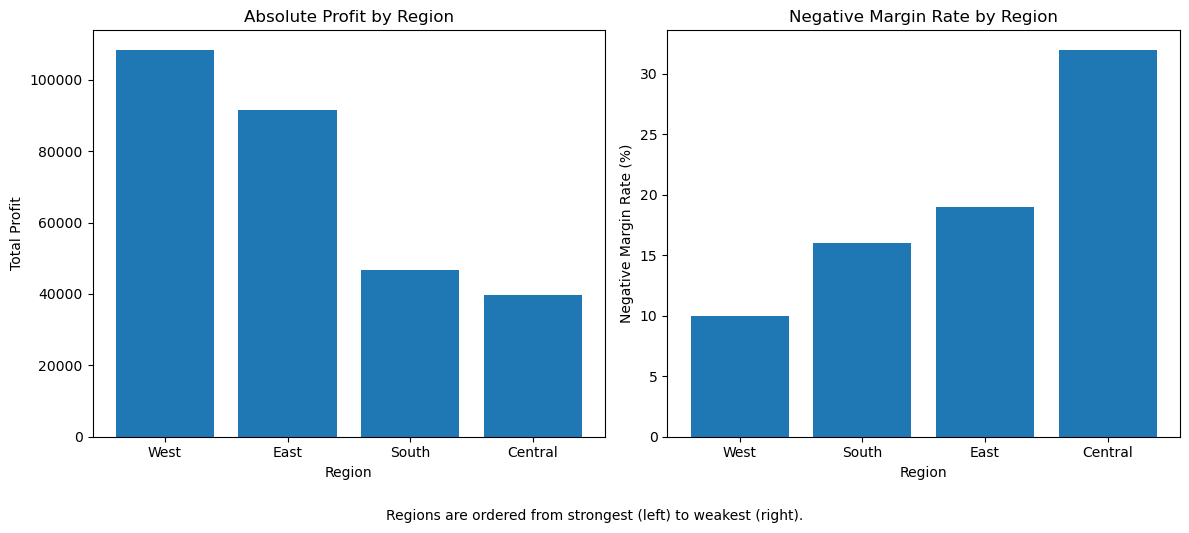

In [14]:
## REGION VISUALS

# sorting target values
region_profit_abs_sorted = region_summary.sort_values(by = 'total_profit', ascending = False)
region_neg_margin_sorted = region_summary.sort_values(by = 'neg_margin_rate', ascending = True)


# plotting absolute profit (value) & negative margin rate (risk)

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 5))

axes[0].bar(
    region_profit_abs_sorted.index,
    region_profit_abs_sorted['total_profit']
)

axes[0].set_title('Absolute Profit by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Profit')

axes[1].bar(
    region_neg_margin_sorted.index,
    region_neg_margin_sorted['neg_margin_rate'] * 100
)

axes[1].set_title('Negative Margin Rate by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Negative Margin Rate (%)')

fig.text(
    0.5, -0.05, 'Regions are ordered from strongest (left) to weakest (right).', ha = 'center', fontsize = 10)

plt.tight_layout()
plt.show()

## Segment Assessment

### *Consumer:*
The Consumer Segment should be **targeted** for growth opportunities. As shown in the profit share by segment visual, the Consumer Segment is leading profit share percentage at approximately 47% of total aggregate profit. The segment exhibits a strong average profit margin of nearly 26%, while a median profit margin of approximately 8.5% indicates that a typical transaction is moderately profitable. The gap between average and median suggests that a subset of high-margin transactions contributes disproportionately to overall profit.

From a risk perspective, 81% of Consumer Segment transactions result in positive profit margins indicating relatively stable performance. However, the segment exhibits a median discount rate of 20%, suggesting that price erosion may be affecting overall profitability.

To improve profit efficiency, discounting strategies within the Consumer Segment should be reviewed and selectively optimized. Gradually reducing discount intensity while monitoring impacts on sales volume, margin, and total profit may help recapture lost margin without materially increasing risk.

### *Corporate:*
The Corporate Segment is another group that should be **targeted** for growth opportunities. As seen in the profit share visual, the Corporate Segment encompasses roughly 32% of aggregate profit, generating approximately \\$92,000 in total profit. The segment exhibits a strong profit efficiency, with an average profit margin of nearly 31%, while a median profit margin of approximately 9% indicates that the typical transaction is moderately profitable. Similar to the previous Consumer Segment, this metric gap suggests high-margin transactions are present within purchasing activity.

Additionally, approximately 82% of Corporate Segment transactions result in profit margin gains, suggesting relatively consistent performance. However, the segment also exhibits a median discount rate of 20%, indicating potential margin erosion driven by discounting practices. 

It is recommended the Corporate Segment engage in similar growth strategies as the Consumer Segment, with an emphasis on selectively optimizing discounting strategies. Gradual reductions in discounting efforts while monitoring for changes in KPI metrics may help improve profitability while maintaining stable demand. 

### *Home Office:*
The Home Office Segment should be **investigated** for growth opportunities within the sector. As shown by the profit share visual, the segment contributes roughly 21% of overall aggregate profit, generating approximately \\$60,200 in total profit. While this trails the Consumer and Corporate segments in profit contribution, the segment demonstrates strong profit quality. An average profit margin of nearly 34%, alongside a median profit margin of approximately 9%, indicates the typical transaction is moderately profitable. The same conclusion can be adapted from the previous segments for the gap in average and median profit margins.

When analyzing for risk, approximately 83% of Home Office Segment transactions result in positive profit margins, reflecting stable performance. Additionally, a median discount rate of 0% suggests profitability is being achieved from current pricing rather than discount-driven sales, indicating strong pricing discipline. 

Despite these strengths, The Home Office Segment trails other segments in scale, with total sales lower by approximately \\$280,000 and total profit by roughly \\$32,000 relative to the next closest segment. This difference suggests that limited demand or reach, rather than weak margin performance, may be constraining growth.

Further investigation should focus on opportunities should focus on opportunities to increase scale while preserving margins. Potential strategies include bundling Home Office with Consumer or Corporate purchases, selectively expanding inventory availability, and exploring targeted advertising initiatives aimed at increasing awareness and demand. These approaches may help grow total profit without introducing margin erosion.

In [15]:
segment_summary = (
    df.groupby('segment').agg(total_sales = ('sales', 'sum'),
                          total_profit = ('profit', 'sum'),
                          avg_profit_margin = ('profit', 'mean'),
                          median_profit_margin = ('profit', 'median'),
                          neg_margin_rate = ('profit_margin', lambda x: (x < 0).mean()),
                          median_discount = ('discount', 'median')
                         )
).round(2)

segment_summary['profit_share_pct'] = round(segment_summary['total_profit'] / segment_summary['total_profit'].sum() * 100, 2)

In [16]:
segment_summary

,total_sales,total_profit,avg_profit_margin,median_profit_margin,neg_margin_rate,median_discount,profit_share_pct
segment,,,,,,,
Consumer,1161401.34,134119.21,25.84,8.38,0.19,0.2,46.83
Corporate,706146.37,91979.13,30.46,8.69,0.18,0.2,32.12
Home Office,429653.15,60298.68,33.82,9.10,0.17,0.0,21.05


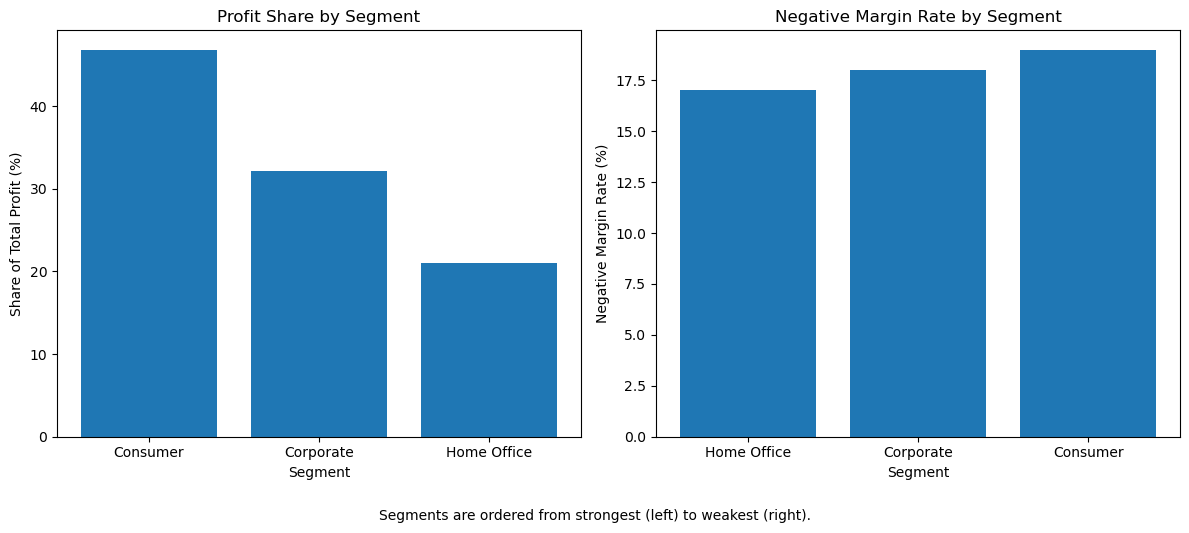

In [17]:
## SEGMENT VISUALS

# sorting target values
segment_profit_share_sorted = segment_summary.sort_values(by = 'profit_share_pct', ascending = False)
segment_neg_margin_sorted = segment_summary.sort_values(by = 'neg_margin_rate', ascending = True)


# plotting profit share by category (value) & negative margin rate (risk)

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 5))

axes[0].bar(
    segment_profit_share_sorted.index,
    segment_profit_share_sorted['profit_share_pct']
)

axes[0].set_title('Profit Share by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Share of Total Profit (%)')

axes[1].bar(
    segment_neg_margin_sorted.index,
    segment_neg_margin_sorted['neg_margin_rate'] * 100
)

axes[1].set_title('Negative Margin Rate by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Negative Margin Rate (%)')

fig.text(
    0.5, -0.05, 'Segments are ordered from strongest (left) to weakest (right).', ha = 'center', fontsize = 10)

plt.tight_layout()
plt.show()

## Predictive Profit Forecasting


In [18]:
# preparing time series data

df['order_date'] = pd.to_datetime(df['order_date'])

df['year_month'] = df['order_date'].dt.to_period('M')

monthly_profit = df.groupby('year_month')['profit'].sum().reset_index()

monthly_profit['year_month'] = monthly_profit['year_month'].dt.to_timestamp()

### Forecasting Approach

Predictive forecasting of total profit was conducted using two approaches: a rolling average model to serve as a baseline benchmark and an Exponential Smoothing (ETS) model to capture underlying time-series structure. The rolling average provides a simple reference by assuming near-term profit will resemble recent historical performance.

The ETS model was selected due to its ability to model level, trend, and seasonal patterns in time-series data while weighting recent observations more heavily. Given the retail context of the Superstore dataset, potential seasonalitywas evaluated by comparing ETS models with and without the seasonal components. Retail activity often experiences elevated purchasing toward the end of the year followed by a decline in early Q1, suggesting seasonality may influence overall profit trends.

### Rolling Average Model

In [19]:
monthly_profit = monthly_profit.set_index('year_month')

# separating train and test sets
train = monthly_profit.iloc[:-int(len(monthly_profit) * 0.2)]
test = monthly_profit.iloc[-int(len(monthly_profit) * 0.2):]

In [20]:
# rolling average model

rolling_window = 3
history = list(train['profit'])
predictions = []

for i in range(len(test)):
    # calculate rolling average from last N observations
    rolling_avg = np.mean(history[-rolling_window:])

    predictions.append(rolling_avg)

    # append actual observations to history
    history.append(test['profit'].iloc[i])

In [21]:
# rolling average model assessment
from sklearn.metrics import mean_absolute_error

mae_baseline = mean_absolute_error(test['profit'], predictions)

mae_baseline

1866.0396703703705

In [22]:
baseline_series = pd.Series(predictions, index = test.index)

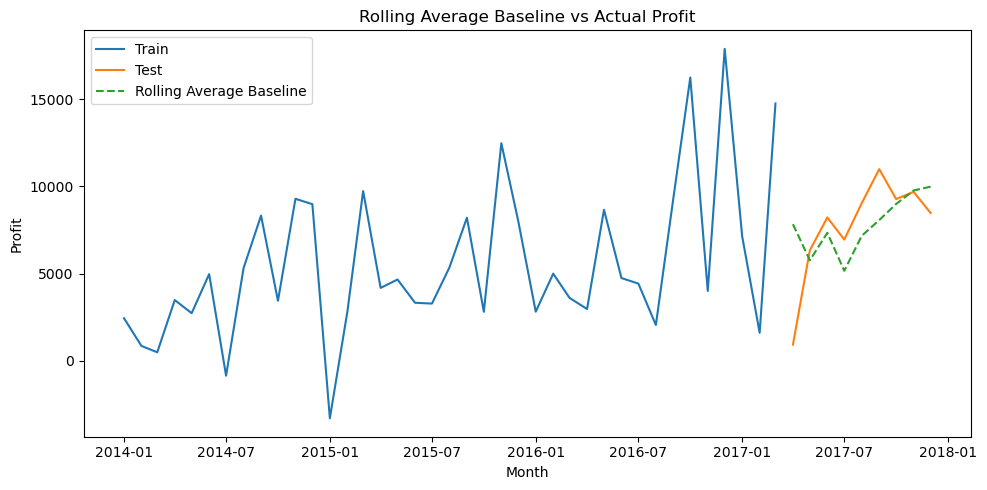

In [23]:
# plotting rolling average

plt.figure(figsize = (10, 5))

# training data
plt.plot(train.index, train['profit'], label = 'Train')

# actual test data
plt.plot(test.index, test['profit'], label = 'Test')

# rolling baseline forecast
plt.plot(test.index, baseline_series, linestyle = '--', label = 'Rolling Average Baseline')

plt.xlabel('Month')
plt.ylabel('Profit')
plt.title('Rolling Average Baseline vs Actual Profit')

plt.legend()
plt.tight_layout()
plt.show()


A 3-month rolling average was used as a baseline forecasting model. This model showed smoothing behavior, lag, and presents the opportunity to utilize a more powerful model to potential capture the profit trend with more precision.

### Exponential Smoothing Model (Non-Seasonal)


In [24]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_no_season = ExponentialSmoothing(train['profit'], trend = 'add', seasonal = None).fit(optimized = True)

ets_forecast_no_season = ets_no_season.forecast(len(test))

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [25]:
# MAE for ETS model without seasonality

mae_ets_no_season = mean_absolute_error(test['profit'], ets_forecast_no_season)

mae_ets_no_season

2466.4297543861535

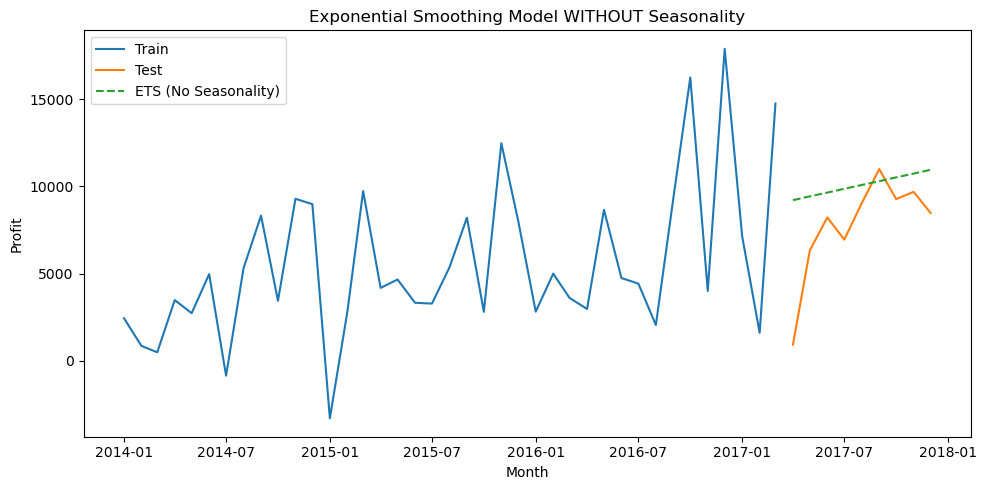

In [26]:
# visualize ETS without seasonality

plt.figure(figsize = (10,5))

plt.plot(train.index, train['profit'], label = 'Train')
plt.plot(test.index, test['profit'], label = 'Test')
plt.plot(test.index, ets_forecast_no_season, linestyle = '--', label = 'ETS (No Seasonality)')

plt.title('Exponential Smoothing Model WITHOUT Seasonality')
plt.xlabel('Month')
plt.ylabel('Profit')

plt.legend()
plt.tight_layout()
plt.show()

### Exponential Smoothing Model (Seasonal)

In [27]:
# seasonal ETS model
ets_seasonality = ExponentialSmoothing(train['profit'], trend = 'add', seasonal = 'add', seasonal_periods = 12).fit(optimized = True)

ets_seasonality_forecast = ets_seasonality.forecast(len(test))

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [28]:
# MAE for ETS model with seasonality

mae_ets_seasonality = mean_absolute_error(test['profit'], ets_seasonality_forecast)

mae_ets_seasonality

2934.257157096027

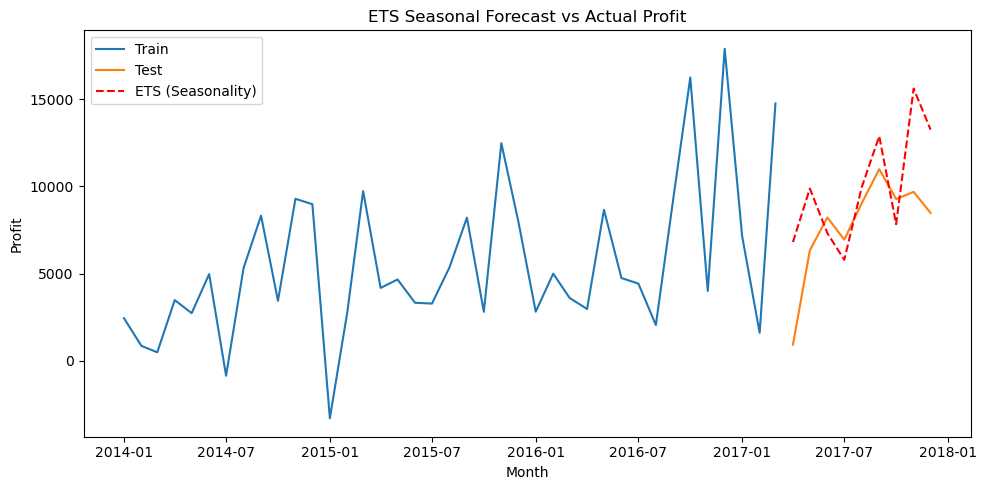

In [29]:
# visualize ETS with seasonality

plt.figure(figsize = (10, 5))

plt.plot(train.index, train['profit'], label = 'Train')
plt.plot(test.index, test['profit'], label = 'Test'),
plt.plot(test.index, ets_seasonality_forecast, linestyle = '--', color = 'red', label = 'ETS (Seasonality)')

plt.title('ETS Seasonal Forecast vs Actual Profit')
plt.xlabel('Month')
plt.ylabel('Profit')

plt.legend()
plt.tight_layout()
plt.show()

### Model Selection and Projection Plan

After evaluating multiple forecasting approaches using a subset of data as a validation set, the 3-month rolling average baseline produced the lowest Mean Absolute Error, outperforming both non-seasonal and seasonal Exponential Smoothing models. Given its higher predictive performance and stability, the rolling average model was selected as the final forecasting approach.

The model was refit using the full historical dataset and used to generate a 6-month forward projection of total profit. This short-term outlook can support strategic decision making related to inventory planning, marketing strategy, and operational resource management based on anticipated profit trends.


In [30]:
# compare MSE between models

results_dict = {
    'Model': ['Rolling Average', 'ETS (No Seasonality)', 'ETS (Seasonality)'],
    'Mean Absolute Error': [mae_baseline, mae_ets_no_season, mae_ets_seasonality]
}

results_df = pd.DataFrame(results_dict).set_index('Model')

results_df

,Mean Absolute Error
Model,
Rolling Average,1866.039670
ETS (No Seasonality),2466.429754
ETS (Seasonality),2934.257157


## Forecasting Results

Although seasonal patterns appear visually plausible within retail contexts, testing showed that incorporating seasonal components did not improve out-of-sample accuracy. The rolling average baseline demonstrated better predictive stability, suggesting that profit behavior in this dataset is more accurately characterized by short-term smoothing rather than stable seasonal structure. This indicates that volatility and noise may be impacting the observable impact of seasonal effects.

In [31]:
# forward looking 6-month projection model

# gathering 6-month rolling averages

history = list(monthly_profit['profit'])

rolling_window = 3
future_periods = 6

future_predictions = []

for i in range(future_periods):
    rolling_average = np.mean(history[-rolling_window:])
    future_predictions.append(rolling_average)
    history.append(rolling_average)

In [32]:
# creating future date index

last_date = monthly_profit.index[-1]

future_dates = pd.date_range(
    start = last_date + pd.DateOffset(months = 1),
    periods = future_periods,
    freq = 'MS'
)

future_series = pd.Series(
    future_predictions,
    index = future_dates
)

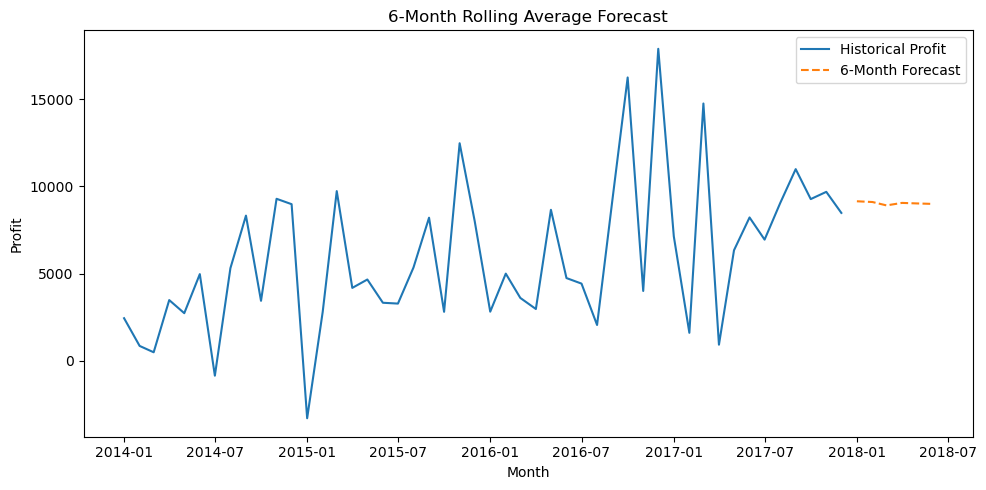

In [33]:
# visualize forward looking forecast

plt.figure(figsize = (10, 5))

plt.plot(monthly_profit.index, monthly_profit['profit'], label = 'Historical Profit')
plt.plot(future_series.index, future_series, linestyle = '--', label = '6-Month Forecast')

plt.title('6-Month Rolling Average Forecast')
plt.xlabel('Month')
plt.ylabel('Profit')

plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

This analysis evaluated Superstore performance across categories, regions, and customer segments using profitability, margin stability, and risk-based metrics. While high sales volume initially appeared promising in certain groups, deeper analysis at the transaction level revealed that profitability consistency and margin health were more reliable indicators of sustainable performance.

From a forecasting perspective, multiple time series approaches were tested using out-of-sample validation. Despite the anticipated usage of seasonal modeling in a retail context, a rolling average baseline provided the most stable and accurate short-term projections. This reinforces the importance of model discipline and empirical validation rather than decisions driven by intuition.

Overall, the findings illustrate that sustainable growth is best achieved through disciplined margin management, targeted expansion in high-performing groups, and evidence-based forecasting. While the dataset presents limitations in scope and duration, the analytical framework applied here provides a structured approach for ongoing performance evaluation and strategic planning. 


## Future Considerations

While the presented insights and projections were derived directly from empirical evidence and methodology, future Superstore analysis can look to expand the research conducted in this report.

First, expanding the historical timeline would strengthen time-series modeling by allowing more reliable identification of trend and seasonal. This dataset’s 4-year lifespan may not be sufficient to allow forecasting models to properly recognize seasonality and reliably project future profit estimations. 

Second, incorporating additional operational variables, such as promotional campaigns, inventory levels, or store-level characteristics, would enable multivariate modeling approaches (e.g., regression-based forecasting or ARIMAX). These additions could improve predictive accuracy by capturing confounding variables of profit performance.

Third, implementing time-series cross validation (walk-forward validation) would further strengthen model robustness and stability across multiple forecast windows.

Finally, deeper analysis on individual products within underperforming categories, particularly Furniture, could isolate specific subcategories or pricing strategies contributing to margin erosion.

Overall, the analytical framework established in this report provides a scalable foundation that can be expanded as additional data and operational inputs become available.
